# 1. Base Setup

In [2]:
import os
import sys
from pathlib import Path

# If notebook is inside <repo>/notebooks/, this moves one level up to repo root
PROJECT_ROOT = Path.cwd().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Current working dir:", Path.cwd().resolve())
print("Project root added to sys.path:", PROJECT_ROOT)
print("cf_copilot exists:", (PROJECT_ROOT / "cf_copilot").exists())


Current working dir: /home/saiyudh/code/EwaltsJ/cf_copilot/notebooks
Project root added to sys.path: /home/saiyudh/code/EwaltsJ/cf_copilot
cf_copilot exists: True


In [3]:
import os
import sys
from pathlib import Path

# If notebook is inside <repo>/notebooks/, this moves one level up to repo root
PROJECT_ROOT = Path.cwd().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Current working dir:", Path.cwd().resolve())
print("Project root added to sys.path:", PROJECT_ROOT)
print("cf_copilot exists:", (PROJECT_ROOT / "cf_copilot").exists())


Current working dir: /home/saiyudh/code/EwaltsJ/cf_copilot/notebooks
Project root added to sys.path: /home/saiyudh/code/EwaltsJ/cf_copilot
cf_copilot exists: True


## 1.1 Install packages

In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
!pip install kagglehub
!pip install statsmodels

## 1.2 Load all needed imports

In [6]:
from pathlib import Path

import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter
import numpy as np
import matplotlib.pyplot as plt

from dateutil.relativedelta import relativedelta

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, log_loss, confusion_matrix
from sklearn.calibration import calibration_curve
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit, GridSearchCV

from scipy.stats import randint
import sys, os
sys.path.append(os.path.abspath(".."))

/home/saiyudh/.pyenv/versions/cf_copilot/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 2. Data Cleaning and preprocessing


In [7]:
import cf_copilot
print(cf_copilot.__file__)

/home/saiyudh/code/EwaltsJ/cf_copilot/cf_copilot/__init__.py


In [8]:
def load_cashflow_data(csv_name: str = "dataset.csv") -> pd.DataFrame:
    """Load invoice dataset from local raw_data folder, or download from Kaggle.

    Args:
        csv_name: filename of the CSV to load.

    Returns:
        A pandas DataFrame with the raw invoice data.
    """
    base_dir = Path.cwd().parent
    raw_data_dir = base_dir / "raw_data"
    raw_data_dir.mkdir(parents=True, exist_ok=True)
    local_path = raw_data_dir / csv_name

    if local_path.is_file():
        print(f"Loading local file: {local_path}")
        return pd.read_csv(local_path)

    print("Local file not found, downloading from Kaggle via kagglehub...")
    df = kagglehub.dataset_load(
        KaggleDatasetAdapter.PANDAS,
        "pradumn203/payment-date-prediction-for-invoices-dataset",
        "dataset.csv",
    )

    df.to_csv(local_path, index=False)
    print(f"Saved local copy to {local_path}")

    return df

In [10]:
from cf_copilot.ml_logic.data import data_cleaning, build_sliding_window_snapshots
from cf_copilot.ml_logic.encoders import preprocess
from cf_copilot.ml_logic.model import initialize_model, train_model,NUMERIC_FEATURES, CATEGORICAL_FEATURES

hist_df = load_cashflow_data()

df = data_cleaning(hist_df)
big_df = build_sliding_window_snapshots(df)

big_df = big_df.sort_values("invoice_sent").reset_index(drop=True)
cutoff_date = big_df["invoice_sent"].quantile(0.8)

train_df = big_df[big_df["reference_date"] <= cutoff_date]
test_df = big_df[big_df["reference_date"] > cutoff_date]

X_train, y_train = preprocess(train_df)
X_test, y_test = preprocess(test_df)

pipeline = initialize_model()
pipeline = pipeline.fit(X_train, y_train)

Loading local file: /home/saiyudh/code/EwaltsJ/cf_copilot/raw_data/dataset.csv
Original rows: 39152
Augmented rows: 98169
week_bucket
0    30568
1    35046
2    14858
3     4331
4     3526
5     2554
6     7286
Name: count, dtype: int64
✅ Model (pipeline) initialized


# 3. Feature selection

## 3.1 show feature importance

In [11]:
def show_feature_importance(pipeline):
    all_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

    # Filter by which ones survived VarianceThreshold
    if "variance" in pipeline.named_steps:
        kept_mask = pipeline.named_steps["variance"].get_support()
        feature_names = all_names[kept_mask]
        feature_names = [name.split("__", 1)[1] for name in feature_names]
    else:
        feature_names = all_names


    importances = pd.DataFrame({
        "feature": feature_names,
        "importance": pipeline.named_steps["classifier"].feature_importances_
    }).sort_values("importance", ascending=False)
    return importances

In [12]:
df = show_feature_importance(pipeline)
df

,feature,importance
2,num__days_until_due,0.205652
6,num__days_past_due,0.201710
3,num__pay_terms_days,0.101167
1,num__invoice_age_days,0.100698
7,num__customer_avg_delay,0.056436
8,num__late_payment_ratio,0.055818
11,num__customer_risk_score,0.048993
9,num__prev_transaction_count,0.037882
18,cat__invoice_currency,0.035434
10,num__days_since_last_invoice,0.018029



Evaluating model on 21811 rows...
✅ Log loss: 0.7762
✅ Top-1 accuracy: 0.7291
✅ Top-2 accuracy: 0.9005

Classification report:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84      7674
           1       0.78      0.74      0.76      8177
           2       0.57      0.62      0.59      3137
           3       0.47      0.28      0.35       864
           4       0.41      0.37      0.39       644
           5       0.56      0.22      0.32       414
           6       0.56      0.64      0.60       901

    accuracy                           0.73     21811
   macro avg       0.59      0.54      0.55     21811
weighted avg       0.72      0.73      0.72     21811

Confusion matrix:
[[6730  650  173   30    8    2   81]
 [1251 6088  654   51   29    7   97]
 [ 140  886 1941   67   30    5   68]
 [  64  100  321  240   72    6   61]
 [  29   33  181   74  236   20   71]
 [  15   23   92   25   95   93   71]
 [  50   47   57   28  110   

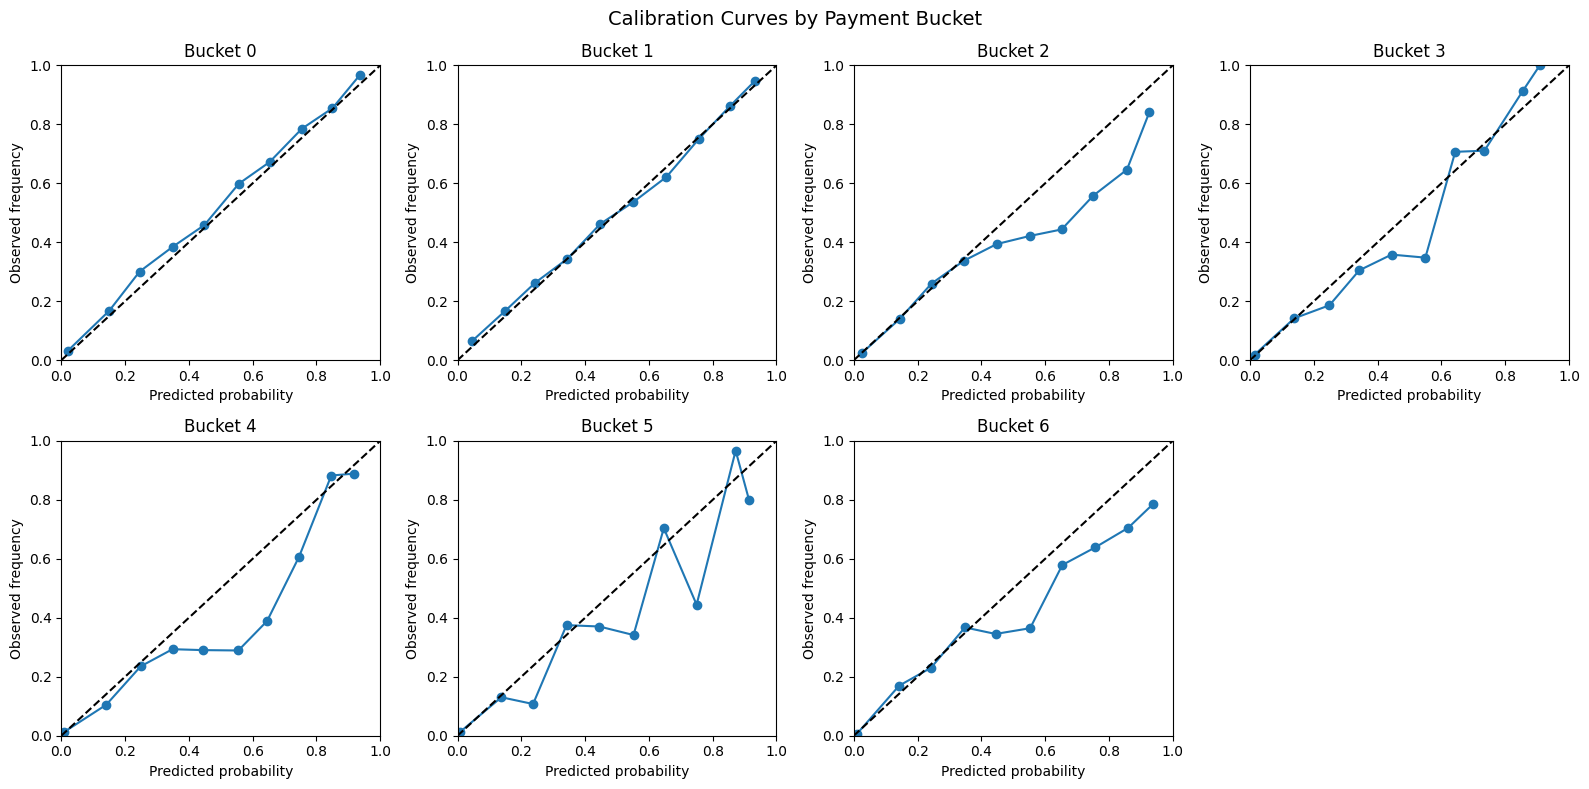

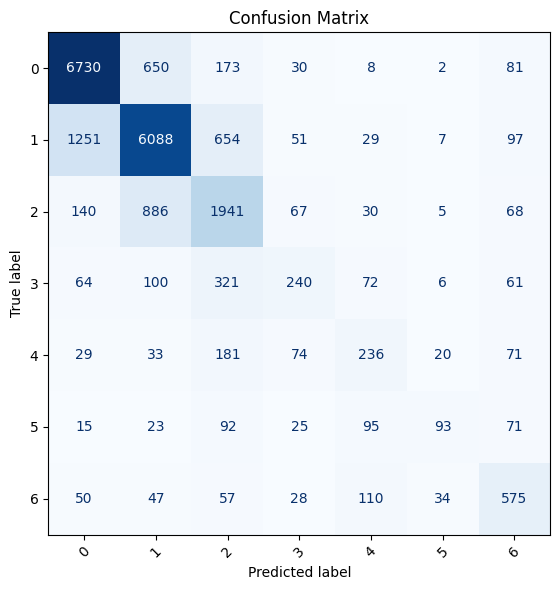

In [13]:
from cf_copilot.ml_logic.evaluation import evaluate_training_run

def evaluate(pipe):
    evaluation_results = evaluate_training_run(pipeline=pipe, X_test=X_test, y_test=y_test,
                                                test_df=test_df, big_df=big_df, log_backtests_to_mlflow=False
    )
    return {
        'metrics': evaluation_results["metrics"],
        # 'figures': evaluation_results["figures"],
        # 'artifacts': evaluation_results["artifacts"],
        # 'forecast_summary': evaluation_results["forecast_summary"],
        # 'backtest_summary': evaluation_results["backtest_summary"],
        'forecast_backtest_summary': evaluation_results["forecast_backtest_summary"]
    }

evaluation = evaluate(pipeline)

In [14]:
evaluation

{'metrics': {'log_loss': 0.7761579871560335,
  'top_1_accuracy': 0.7291275044702215,
  'top_2_accuracy': 0.9005089175186832,
  'forecast_mae_weekly': 1318619.7531818182,
  'forecast_mape_weekly': 0.5281818181818182,
  'forecast_total_actual_cf': 30433551.419090904,
  'forecast_total_forecast_cf': 30164880.409090914,
  'forecast_total_cf_difference': -268671.01},
 'forecast_backtest_summary': {'per_cutoff': [{'cutoff': '2019-06-25',
    'forecast_mae_weekly': 1561552.9549999998,
    'forecast_mape_weekly': 0.3433333333333333},
   {'cutoff': '2019-08-12',
    'forecast_mae_weekly': 1957240.3866666667,
    'forecast_mape_weekly': 0.4816666666666667},
   {'cutoff': '2019-09-29',
    'forecast_mae_weekly': 2036431.5099999998,
    'forecast_mape_weekly': 0.4583333333333333},
   {'cutoff': '2019-11-17',
    'forecast_mae_weekly': 1925346.43,
    'forecast_mape_weekly': 0.46166666666666667},
   {'cutoff': '2020-01-04',
    'forecast_mae_weekly': 1265459.51,
    'forecast_mape_weekly': 0.543333

## 3.2  Add variance

In [15]:
from sklearn.feature_selection import VarianceThreshold

# Insert VarianceThreshold in existing pipeline, this drops near-constant features
new_pipeline = Pipeline([
    ("preprocessor", pipeline.named_steps["preprocessor"]),
    ("variance", VarianceThreshold(threshold=0.05)),
    ("classifier", pipeline.named_steps["classifier"]),
])
new_pipeline.fit(X_train, y_train)
show_feature_importance(new_pipeline)


,feature,importance
1,days_until_due,0.231838
5,days_past_due,0.175837
2,pay_terms_days,0.101827
0,invoice_age_days,0.093734
10,customer_risk_score,0.056935
7,late_payment_ratio,0.056431
6,customer_avg_delay,0.052463
8,prev_transaction_count,0.038496
17,invoice_currency,0.033637
9,days_since_last_invoice,0.018646



Evaluating model on 21811 rows...
✅ Log loss: 0.7781
✅ Top-1 accuracy: 0.7285
✅ Top-2 accuracy: 0.8992

Classification report:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84      7674
           1       0.78      0.74      0.76      8177
           2       0.57      0.62      0.59      3137
           3       0.46      0.28      0.34       864
           4       0.40      0.36      0.38       644
           5       0.53      0.22      0.32       414
           6       0.56      0.63      0.59       901

    accuracy                           0.73     21811
   macro avg       0.59      0.53      0.55     21811
weighted avg       0.72      0.73      0.72     21811

Confusion matrix:
[[6735  649  167   30   10    3   80]
 [1260 6085  640   51   35    7   99]
 [ 137  889 1939   69   29    5   69]
 [  56  103  324  238   72    8   63]
 [  28   37  185   73  232   23   66]
 [  15   24   91   26   94   93   71]
 [  49   48   57   29  115   

{'metrics': {'log_loss': 0.7780903239067604,
  'top_1_accuracy': 0.7284856265187291,
  'top_2_accuracy': 0.8991793131905919,
  'forecast_mae_weekly': 1322333.8490909091,
  'forecast_mape_weekly': 0.5281818181818182,
  'forecast_total_actual_cf': 30433551.419090904,
  'forecast_total_forecast_cf': 30174580.592272732,
  'forecast_total_cf_difference': -258970.82681818187},
 'forecast_backtest_summary': {'per_cutoff': [{'cutoff': '2019-06-25',
    'forecast_mae_weekly': 1561998.0466666666,
    'forecast_mape_weekly': 0.35166666666666674},
   {'cutoff': '2019-08-12',
    'forecast_mae_weekly': 1936329.0283333333,
    'forecast_mape_weekly': 0.4816666666666667},
   {'cutoff': '2019-09-29',
    'forecast_mae_weekly': 2008032.9266666668,
    'forecast_mape_weekly': 0.4483333333333333},
   {'cutoff': '2019-11-17',
    'forecast_mae_weekly': 1920912.2966666669,
    'forecast_mape_weekly': 0.46166666666666667},
   {'cutoff': '2020-01-04',
    'forecast_mae_weekly': 1261127.65,
    'forecast_mape

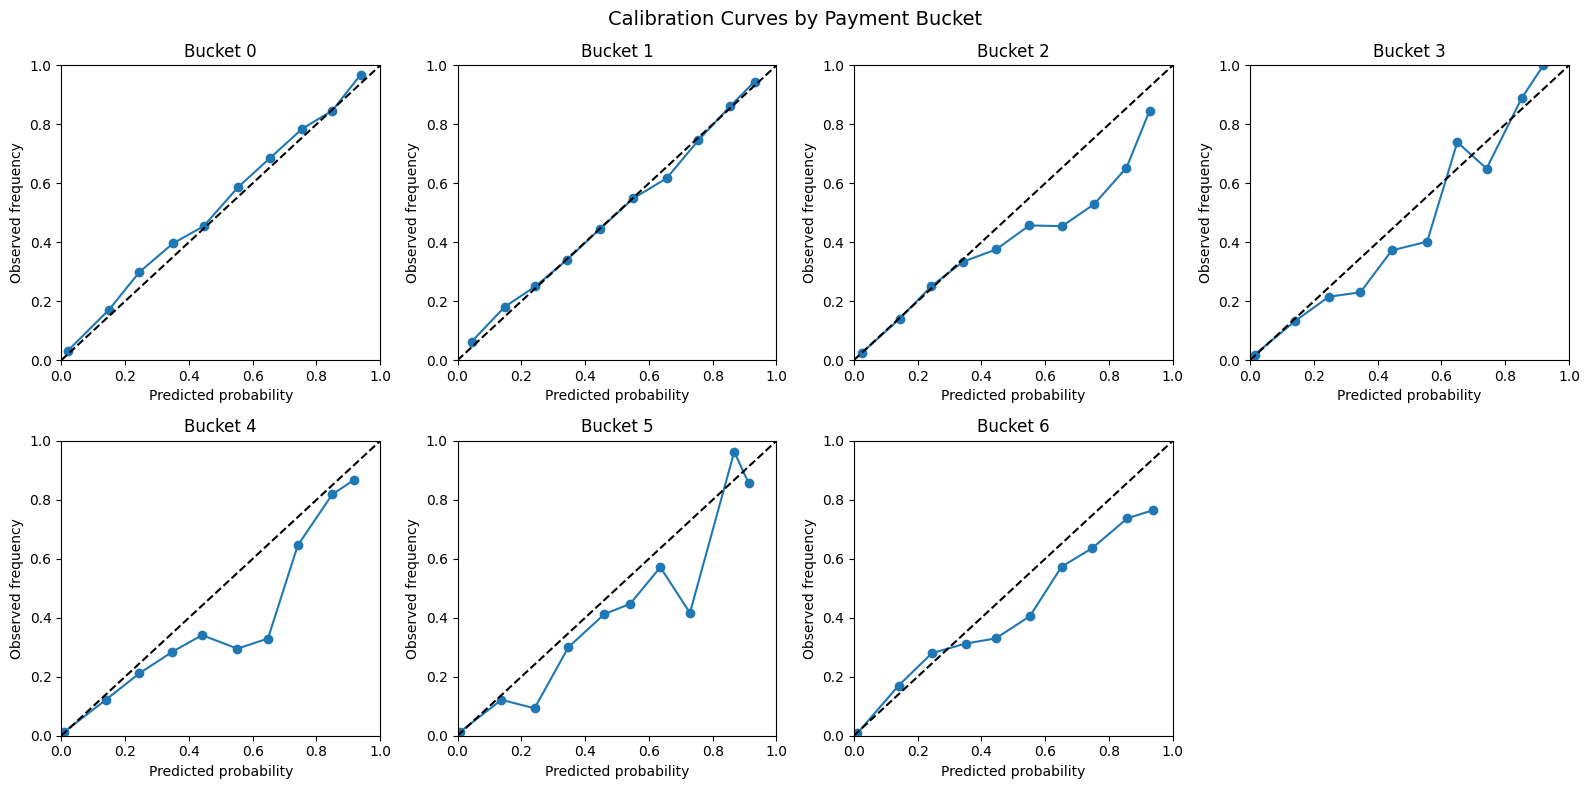

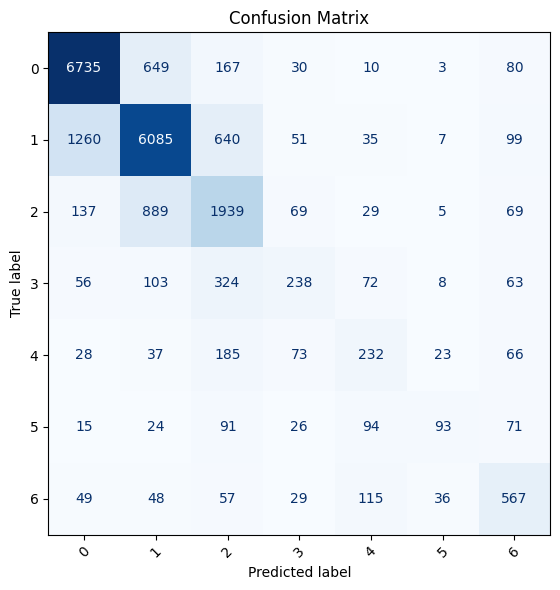

In [16]:
evaluate(new_pipeline)

## 3.3 Permutation importance

### Permutation Importance — What does it mean?

Permutation importance works by shuffling one feature at a time and checking how much the model's performance drops. If the score drops a lot, that feature is important. If nothing changes, the feature isn't doing anything useful.

How to read the values:
- **importance_mean > 0** (e.g. 0.05): shuffling this feature made the model worse by 0.05. Good — it means the feature matters. Higher = more important.
- **importance_mean ≈ 0** (e.g. 0.001): the feature barely contributes anything. Could probably drop it.
- **importance_mean < 0** (e.g. -0.01): the model actually got *better* when we shuffled this feature. It's just adding noise — should definitely drop it.

importance_std shows how stable the result is across repeats. If importance_std is bigger than importance_mean, the result isn't very reliable and we can't really trust that feature's score.

One thing to watch out for: if two features are highly correlated, they'll both show lower importance than expected because shuffling one still leaves the other intact. So it's worth checking multicollinearity before drawing conclusions from this.

We're using X_test here instead of X_train to avoid overfit features looking more important than they actually are.

In [17]:
from sklearn.inspection import permutation_importance
X_pre = pipeline.named_steps["preprocessor"].fit_transform(X_train, y_train)

perm = permutation_importance(new_pipeline, X_train, y_train, n_repeats=10, scoring='neg_log_loss')

In [18]:
feature_names = new_pipeline.named_steps["preprocessor"].get_feature_names_out()

perm_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

perm_df

,feature,importance_mean,importance_std
4,num__invoice_month,0.546895,0.001553
3,num__pay_terms_days,0.221152,0.001673
15,num__invoice_month_cos,0.161291,0.000927
5,num__due_month,0.107362,0.000501
14,num__invoice_month_sin,0.105866,0.000728
13,num__invoice_amount_log,0.088557,0.000390
8,num__late_payment_ratio,0.067030,0.000383
16,num__due_month_sin,0.057725,0.000389
18,cat__invoice_currency,0.034149,0.000285
17,num__due_month_cos,0.029935,0.000327


## 3.4 Automatic feature selection with CrossValidate

### RFECV — Recursive Feature Elimination with Cross Validation

RFECV works by repeatedly removing the least important feature, refitting the model each time, and checking the cross-validated score. It keeps doing this until it finds the smallest set of features that still gives the best performance.

How to read the results:
- **rfecv.n_features_**: the optimal number of features it found.
- **rfecv.support_**: a boolean mask showing which features were kept (True) and which were dropped (False).
- **rfecv.ranking_**: ranking per feature — 1 means it was selected, higher numbers mean it was eliminated earlier.
- **rfecv.cv_results_["mean_test_score"]**: the CV score at each step, useful to plot and see where performance peaks.



If the curve flattens out early, it means a lot of features aren't really helping and we can safely use a smaller set. If it keeps climbing until the end, we probably need all of them.

In [20]:
# This takes quite some time with our current number of features, so be aware

from sklearn.feature_selection import RFECV
X_pre = pipeline.named_steps["preprocessor"].fit_transform(X_train, y_train)

rfecv = RFECV(
    estimator=pipeline.named_steps["classifier"],
    step=1,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)
rfecv.fit(X_pre, y_train)
X_selected = rfecv.transform(X_train)

rfecv_df = pd.DataFrame({
    "feature": feature_names,
    "selected": rfecv.support_,
    "ranking": rfecv.ranking_,
}).sort_values("ranking")

rfecv_df

Fitting estimator with 22 features.
Fitting estimator with 22 features.
Fitting estimator with 22 features.
Fitting estimator with 22 features.
Fitting estimator with 22 features.
Fitting estimator with 21 features.
Fitting estimator with 21 features.
Fitting estimator with 21 features.
Fitting estimator with 21 features.
Fitting estimator with 21 features.
Fitting estimator with 20 features.
Fitting estimator with 20 features.
Fitting estimator with 20 features.
Fitting estimator with 20 features.
Fitting estimator with 20 features.
Fitting estimator with 19 features.
Fitting estimator with 19 features.
Fitting estimator with 19 features.
Fitting estimator with 19 features.
Fitting estimator with 19 features.
Fitting estimator with 18 features.
Fitting estimator with 18 features.
Fitting estimator with 18 features.
Fitting estimator with 18 features.
Fitting estimator with 18 features.
Fitting estimator with 17 features.
Fitting estimator with 17 features.
Fitting estimator with 17 fe

/home/saiyudh/.pyenv/versions/cf_copilot/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RFECV was fitted without feature names
  warnings.warn(


,feature,selected,ranking
1,num__invoice_age_days,True,1
2,num__days_until_due,True,1
3,num__pay_terms_days,True,1
6,num__days_past_due,True,1
7,num__customer_avg_delay,True,1
8,num__late_payment_ratio,True,1
9,num__prev_transaction_count,True,1
11,num__customer_risk_score,True,1
18,cat__invoice_currency,False,2
10,num__days_since_last_invoice,False,3


In [21]:
all_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
print(all_names)

['num__business_year' 'num__invoice_age_days' 'num__days_until_due'
 'num__pay_terms_days' 'num__invoice_month' 'num__due_month'
 'num__days_past_due' 'num__customer_avg_delay' 'num__late_payment_ratio'
 'num__prev_transaction_count' 'num__days_since_last_invoice'
 'num__customer_risk_score' 'num__invoice_amount'
 'num__invoice_amount_log' 'num__invoice_month_sin'
 'num__invoice_month_cos' 'num__due_month_sin' 'num__due_month_cos'
 'cat__invoice_currency' 'cat__document_type' 'cat__invoice_size_cat'
 'cat__invoice_size_cat_q']


In [22]:
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
selected_names = feature_names[rfecv.support_]
selected_names = [name.split("__", 1)[1] for name in selected_names]

X_selected_df = pd.DataFrame(X_selected, columns=selected_names)
X_selected_df.head()

,invoice_age_days,days_until_due,pay_terms_days,days_past_due,customer_avg_delay,late_payment_ratio,prev_transaction_count,customer_risk_score
0,USD,RV,0.0,12,12,-15,-0.0,-0.0
1,USD,RV,49.0,12,12,34,-0.0,-0.0
2,USD,RV,56.0,12,12,41,-0.0,-0.0
3,USD,RV,63.0,12,12,48,-0.0,-0.0
4,CAD,RV,35.0,12,12,25,-0.0,-0.0


# 4. Multicoliniarity

How to interpret VIF:

- VIF < 5 → fine
- VIF 5–10 → moderate, keep an eye on it
- VIF > 10 → strong multicollinearity, consider dropping one of the correlated pair

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_pre = pipeline.named_steps["preprocessor"].transform(X_train)
feature_names = [n.split("__", 1)[1] for n in pipeline.named_steps["preprocessor"].get_feature_names_out()]

vif_df = pd.DataFrame({
    "feature": feature_names,
    "VIF": [variance_inflation_factor(X_pre, i) for i in range(X_pre.shape[1])]
}).sort_values("VIF", ascending=False)

vif_df

/home/saiyudh/.pyenv/versions/cf_copilot/lib/python3.10/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/home/saiyudh/.pyenv/versions/cf_copilot/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,feature,VIF
2,days_until_due,inf
3,pay_terms_days,inf
6,days_past_due,inf
7,customer_avg_delay,inf
8,late_payment_ratio,inf
1,invoice_age_days,inf
11,customer_risk_score,inf
0,business_year,265.851690
14,invoice_month_sin,15.660572
5,due_month,15.645190
